In [1]:
import sys

# Add parent directory to path for imports
sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/")

import matplotlib.pyplot as plt
import numpy as np
import pickle
from tqdm import tqdm
import pandas as pd
import json
from pathlib import Path

In [2]:
def load_data(
    df_metadata,
    cart_position=None,
    pole_angle=None,
    normalization_method=None,
    seed=None,
):
    """
    Load intervention data from directories matching the specified criteria.
    
    Parameters can be single values or lists. If a parameter is None, it matches all values.
    
    Returns:
        pd.DataFrame: DataFrame with config info and episode data
    """

    # Convert single values to lists for uniform handling
    def to_list(val):
        if val is None:
            return None
        return val if isinstance(val, list) else [val]

    cart_position_list = to_list(cart_position)
    pole_angle_list = to_list(pole_angle)
    seed_list = to_list(seed)
    normalization_list = to_list(normalization_method)

    # Filter configs based on criteria
    filtered_configs = []
    for idx, config in df_metadata.iterrows():
        inital_state = config.get('initial_state')
        # Check each criterion
        if cart_position_list is not None and inital_state[
                0] not in cart_position_list:
            continue
        if pole_angle_list is not None and inital_state[
                1] not in pole_angle_list:
            continue
        if normalization_list is not None and config.get(
                'normalization_method') not in normalization_list:
            continue
        if seed_list is not None and config.get('config_seed') not in seed_list:
            continue

        filtered_configs.append(config)

    print(f"Found {len(filtered_configs)} configurations")
    # Load episode data for each matching config
    results = []
    for config in tqdm(filtered_configs):
        directory = Path(config['directory'])
        episode_path = directory / "activations" / "episode_0000.pkl"

        if episode_path.exists():
            # Load the pickled episode data
            with open(episode_path, 'rb') as f:
                episode_data = pickle.load(f)

            # Unflatten the data structure
            episode_data = episode_data['data']
            for key, value in episode_data.items():

                if key == 'latent_states':
                    config[key] = value.squeeze()
                else:
                    config[key] = value

            results.append(config)

    return pd.DataFrame(results)


def flatten_dict(d, parent_key='', sep='_'):
    """
    Flatten a nested dictionary.
    
    Args:
        d: Dictionary to flatten
        parent_key: String to prepend to keys
        sep: Separator between nested keys
    
    Returns:
        Flattened dictionary
    """
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        else:
            items.append((new_key, v))
    return dict(items)


In [3]:
def compute_success(df_data,
                    threshold_angle=0.1,
                    consecutive_steps=100,
                    column_name=None):
    """
    Compute whether the pole is upright (straight) for consecutive_steps time points.
    
    Args:
        df_data: DataFrame with 'observations' column containing state arrays
        threshold_angle: Maximum angle deviation from vertical (in radians) to consider "straight"
        consecutive_steps: Number of consecutive steps required for success
    
    Returns:
        df_data: DataFrame with added 'success' column
    """
    success = []

    for idx in range(len(df_data)):
        observations = np.array(df_data['observations'].iloc[idx])

        # Extract cos and sin of pole angle (dimensions 1 and 2)
        cos_angle = observations[:, 1]
        sin_angle = observations[:, 2]

        # Compute actual angle from cos and sin
        angles = np.arctan2(sin_angle, cos_angle)

        # Check if angle is within threshold (close to 0, which is upright)
        is_straight = np.abs(angles) < threshold_angle

        # Check for consecutive_steps consecutive True values
        episode_success = False
        count = 0
        for straight in is_straight:
            if straight:
                count += 1
                if count >= consecutive_steps:
                    episode_success = True
                    break
            else:
                count = 0

        success.append(episode_success)
    column_name = column_name if column_name is not None else 'success'
    df_data[column_name] = np.array(success)
    return df_data

In [6]:
# Loop over all directories in the sweep logs
sweep_base_dir = Path("logs/281125-latent_intervention_control_sweep")

all_metadata = []
for sweep_dir in sweep_base_dir.iterdir():
    if sweep_dir.is_dir():
        metadata_path = sweep_dir / "activations" / "episode_0000_metadata.json"
        if metadata_path.exists():
            with open(metadata_path, 'r') as f:
                try:
                    metadata = json.load(f)
                    # Flatten the nested metadata dictionary
                    flattened_metadata = flatten_dict(metadata)
                    # Add the directory path
                    flattened_metadata['directory'] = str(sweep_dir)
                    all_metadata.append(flattened_metadata)
                except json.JSONDecodeError:
                    print(f"Error decoding JSON for {metadata_path}")
                    continue

print(f"Found {len(all_metadata)} configurations")
# Create DataFrame from flattened metadata

df_metadata = pd.DataFrame(all_metadata)


Found 1506 configurations


In [19]:
df = load_data(
    df_metadata[df_metadata['config_direction_str'] ==
                'backprop_gradient_nonlinear_position'],
    cart_position=None,
    pole_angle=None,
    seed=None,
)
#normalization_method='simnorm')

Found 33 configurations


100%|██████████| 33/33 [00:00<00:00, 84.15it/s]


In [20]:
seed_counts = df.groupby('config_seed').size()
print(seed_counts)

config_seed
1    11
2    11
3    11
dtype: int64


In [21]:
df['config_hinge_1_value_degrees'] = np.degrees(df['config_hinge_1_value'])
df['hinge_str'] = df['config_hinge_1_value_degrees'].round(0).astype(str)

In [22]:
df.head()

,config_type,config_location,config_direction,config_magnitude,config_hinge_1_value,config_seed,config_normalization_method,checkpoint,episode_idx,episode_length,...,config_start_step,config_end_step,observations,actions,rewards,dones,latent_states,timesteps,config_hinge_1_value_degrees,hinge_str
2,directional_addition,encoder_output,"[-0.1863662451505661, 0.01824766956269741, 0.0...",2.5,0.0,1,None,/home/hgf_hmgu/hgf_gib4562/tdmpc2/ckpts/cartpo...,0,500,...,10.0,NaN,"[[0.016243454, 1.0, 0.0, -0.0052817175, -0.010...","[[-0.026575988], [0.028191585], [-0.012010125]...","[1.9995650053024292, 1.999527096748352, 1.9997...","[False, False, False, False, False, False, Fal...","[[0.011337483, 0.18699004, 0.6265908, 0.032347...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0.0,0.0
121,directional_addition,encoder_output,"[-0.1863662451505661, 0.01824766956269741, 0.0...",5.0,0.0,1,None,/home/hgf_hmgu/hgf_gib4562/tdmpc2/ckpts/cartpo...,0,500,...,10.0,NaN,"[[0.016243454, 1.0, 0.0, -0.0052817175, -0.010...","[[-0.026575988], [0.028191585], [-0.012010125]...","[1.9995650053024292, 1.999527096748352, 1.9997...","[False, False, False, False, False, False, Fal...","[[0.011337483, 0.18699004, 0.6265908, 0.032347...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0.0,0.0
146,directional_addition,encoder_output,"[-0.1863662451505661, 0.01824766956269741, 0.0...",-10.0,0.0,3,None,/home/hgf_hmgu/hgf_gib4562/tdmpc2/ckpts/cartpo...,0,500,...,10.0,NaN,"[[0.016243454, 1.0, 0.0, -0.0052817175, -0.010...","[[-0.023053946], [-0.03559512], [-0.009218976]...","[1.9996341466903687, 1.9993460178375244, 1.999...","[False, False, False, False, False, False, Fal...","[[0.011337483, 0.18699004, 0.6265908, 0.032347...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0.0,0.0
227,directional_addition,encoder_output,"[-0.1863662451505661, 0.01824766956269741, 0.0...",10.0,0.0,1,None,/home/hgf_hmgu/hgf_gib4562/tdmpc2/ckpts/cartpo...,0,500,...,10.0,NaN,"[[0.016243454, 1.0, 0.0, -0.0052817175, -0.010...","[[-0.026575988], [0.028191585], [-0.012010125]...","[1.9995650053024292, 1.999527096748352, 1.9997...","[False, False, False, False, False, False, Fal...","[[0.011337483, 0.18699004, 0.6265908, 0.032347...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0.0,0.0
229,directional_addition,encoder_output,"[-0.1863662451505661, 0.01824766956269741, 0.0...",2.5,0.0,3,None,/home/hgf_hmgu/hgf_gib4562/tdmpc2/ckpts/cartpo...,0,500,...,10.0,NaN,"[[0.016243454, 1.0, 0.0, -0.0052817175, -0.010...","[[-0.023053946], [-0.03559512], [-0.009218976]...","[1.9996341466903687, 1.9993460178375244, 1.999...","[False, False, False, False, False, False, Fal...","[[0.011337483, 0.18699004, 0.6265908, 0.032347...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0.0,0.0


## Analysis: does the cart move right/left depending on the alpha?

In [23]:
# varsname_dict = {
#     0: 'cart position',
#     1: 'cos(pole angle)',
#     2: 'sin(pole angle)',
#     3: 'cart velocity',
#     4: 'pole angular velocity',
# }


In [24]:
for dim in range(5):
    df[f'average_dim_{dim}'] = df['observations'].apply(
        lambda x: np.mean(np.array(x)[:, dim]))

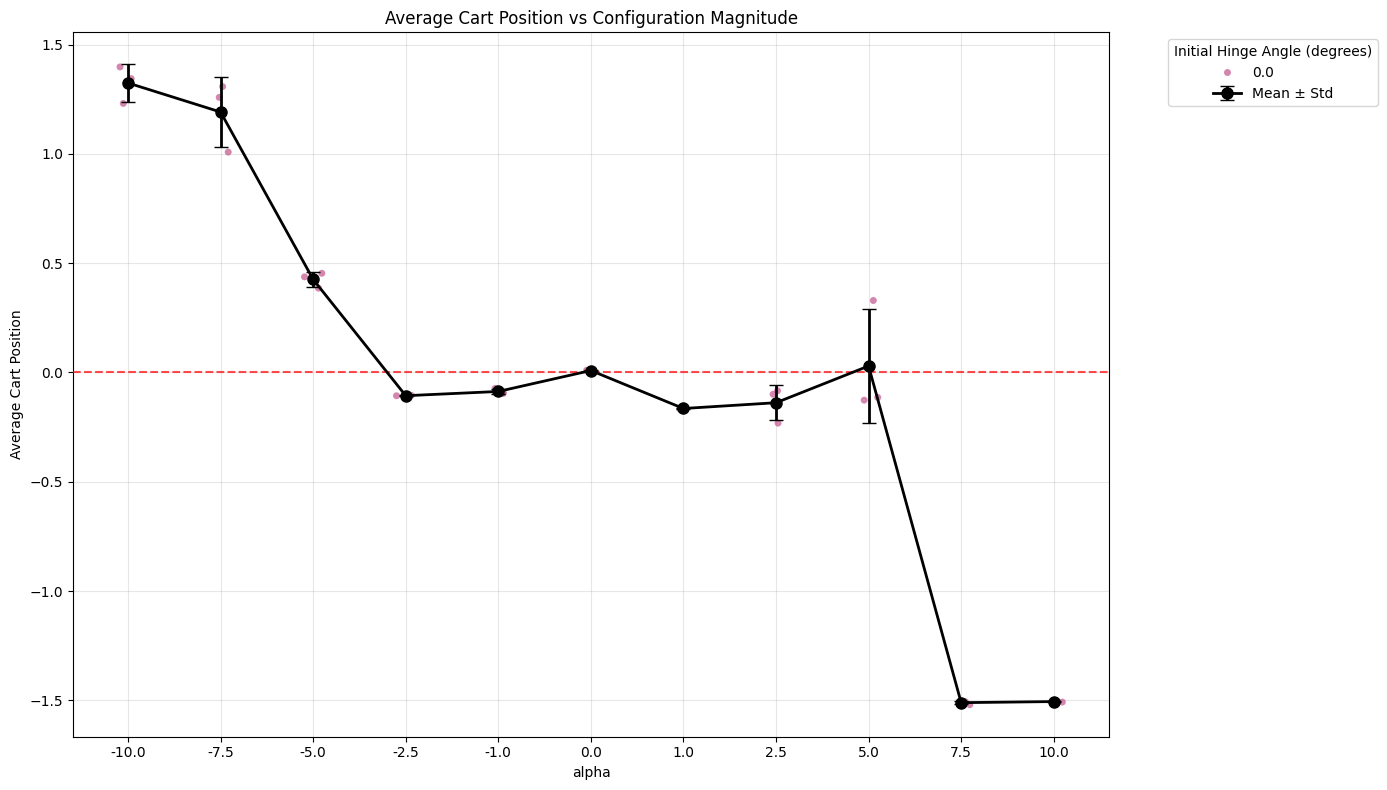

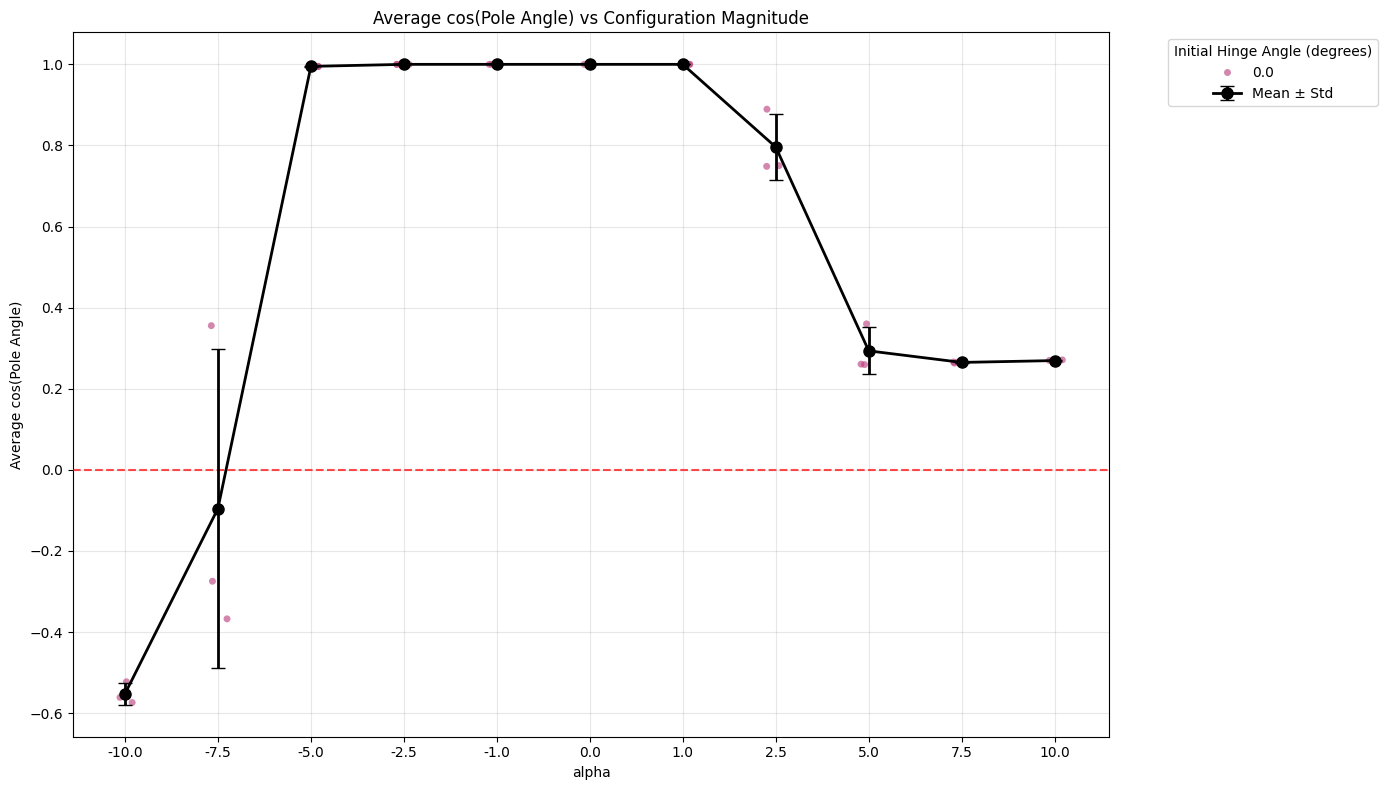

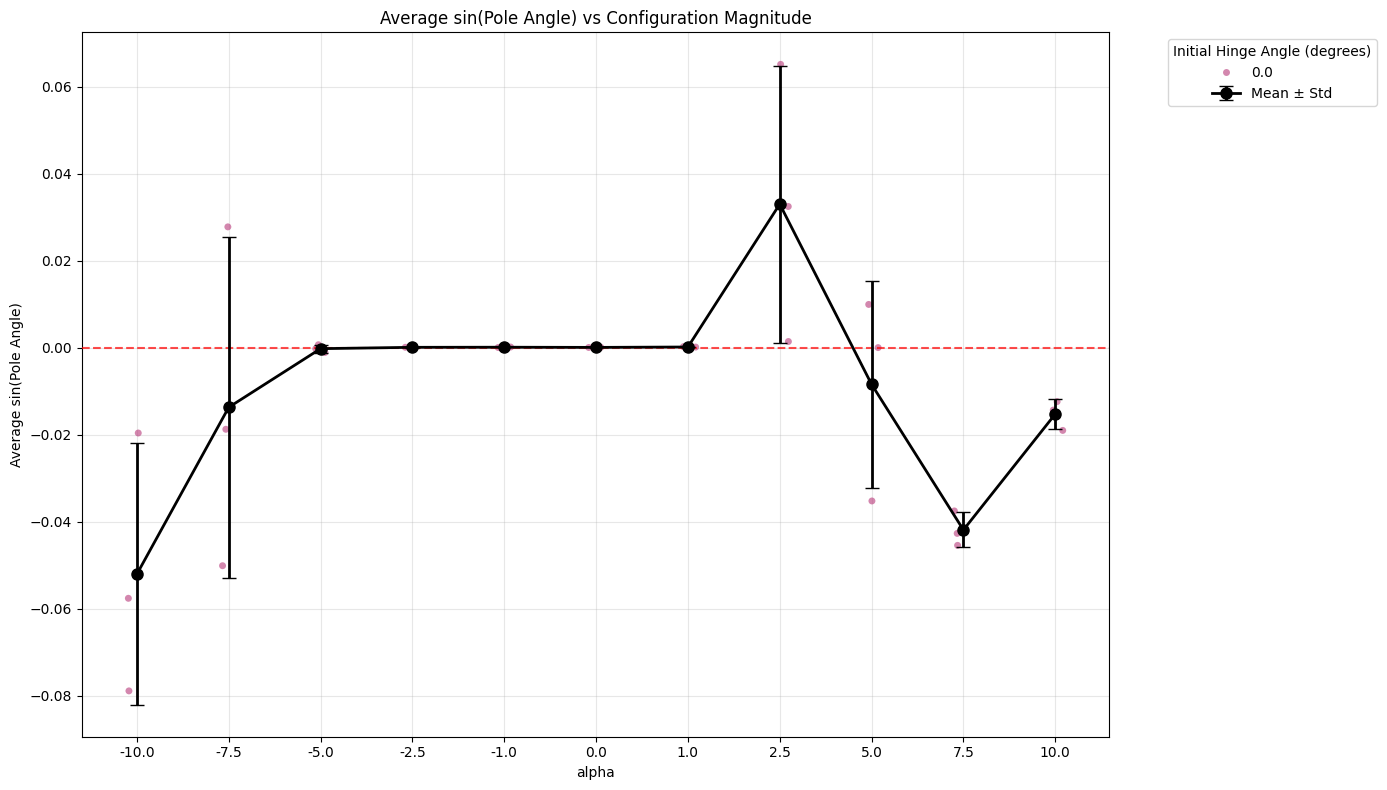

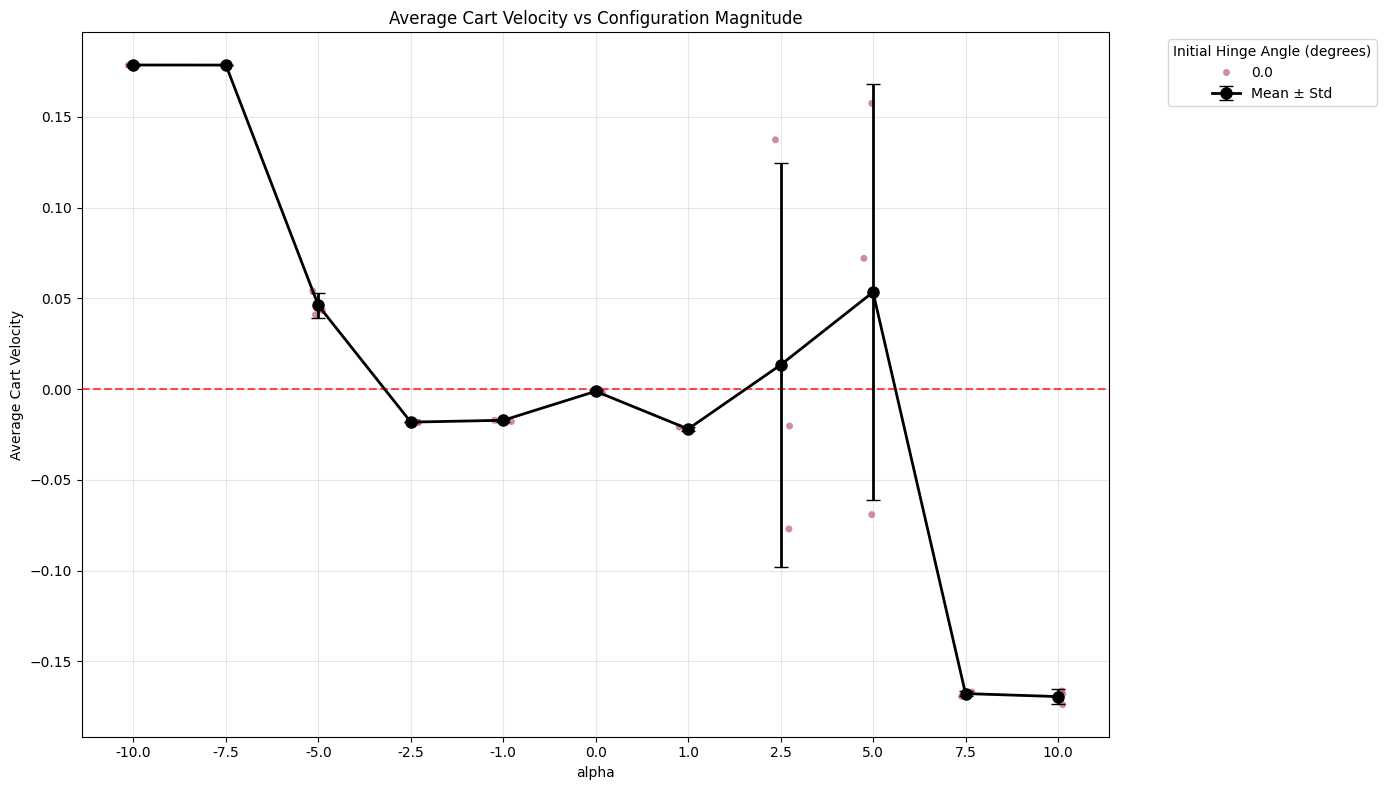

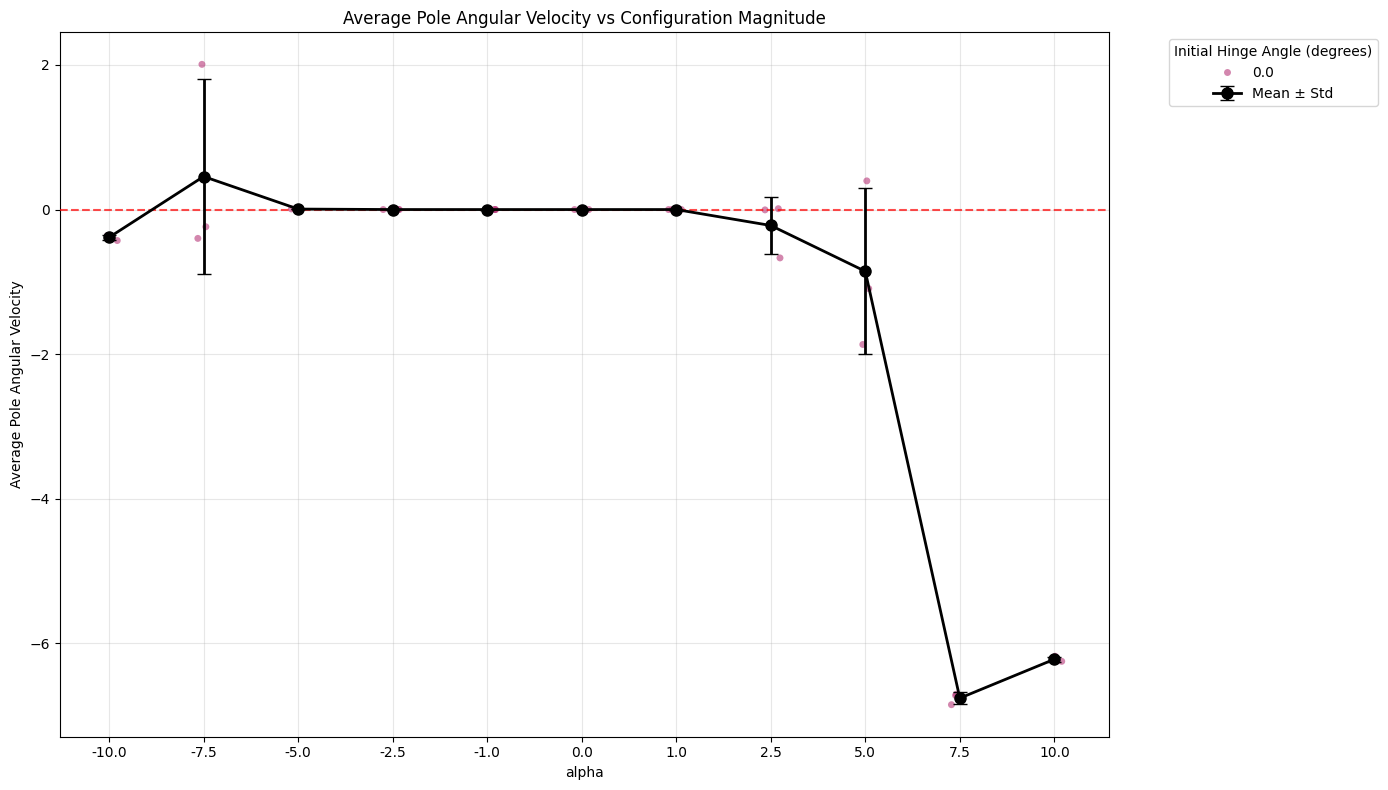

In [25]:
import seaborn as sns

dim_names = {
    0: 'Cart Position',
    1: 'cos(Pole Angle)',
    2: 'sin(Pole Angle)',
    3: 'Cart Velocity',
    4: 'Pole Angular Velocity',
}

for dim in range(5):
    plt.figure(figsize=(14, 8))
    sns.stripplot(data=df,
                  x='config_magnitude',
                  y=f'average_dim_{dim}',
                  hue='hinge_str',
                  hue_order=sorted(df['hinge_str'].unique(),
                                   key=lambda x: float(x)),
                  alpha=0.6,
                  palette='magma')

    # Calculate mean and std per config_magnitude
    grouped = df.groupby('config_magnitude')[f'average_dim_{dim}'].agg(
        ['mean', 'std'])
    x_positions = range(len(grouped))
    magnitudes = grouped.index

    # Plot mean with error bars
    plt.errorbar(x_positions,
                 grouped['mean'],
                 yerr=grouped['std'],
                 fmt='-o',
                 color='black',
                 markersize=8,
                 capsize=5,
                 linewidth=2,
                 label='Mean ± Std',
                 zorder=10)

    # Add horizontal line at y=0
    plt.axhline(y=0,
                color='red',
                linestyle='--',
                linewidth=1.5,
                alpha=0.7,
                zorder=5)

    plt.xlabel('alpha')
    plt.ylabel(f'Average {dim_names[dim]}')
    plt.title(f'Average {dim_names[dim]} vs Configuration Magnitude')
    plt.grid(True, alpha=0.3)
    plt.legend(title='Initial Hinge Angle (degrees)',
               bbox_to_anchor=(1.05, 1),
               loc='upper left')
    plt.tight_layout()
    plt.show()


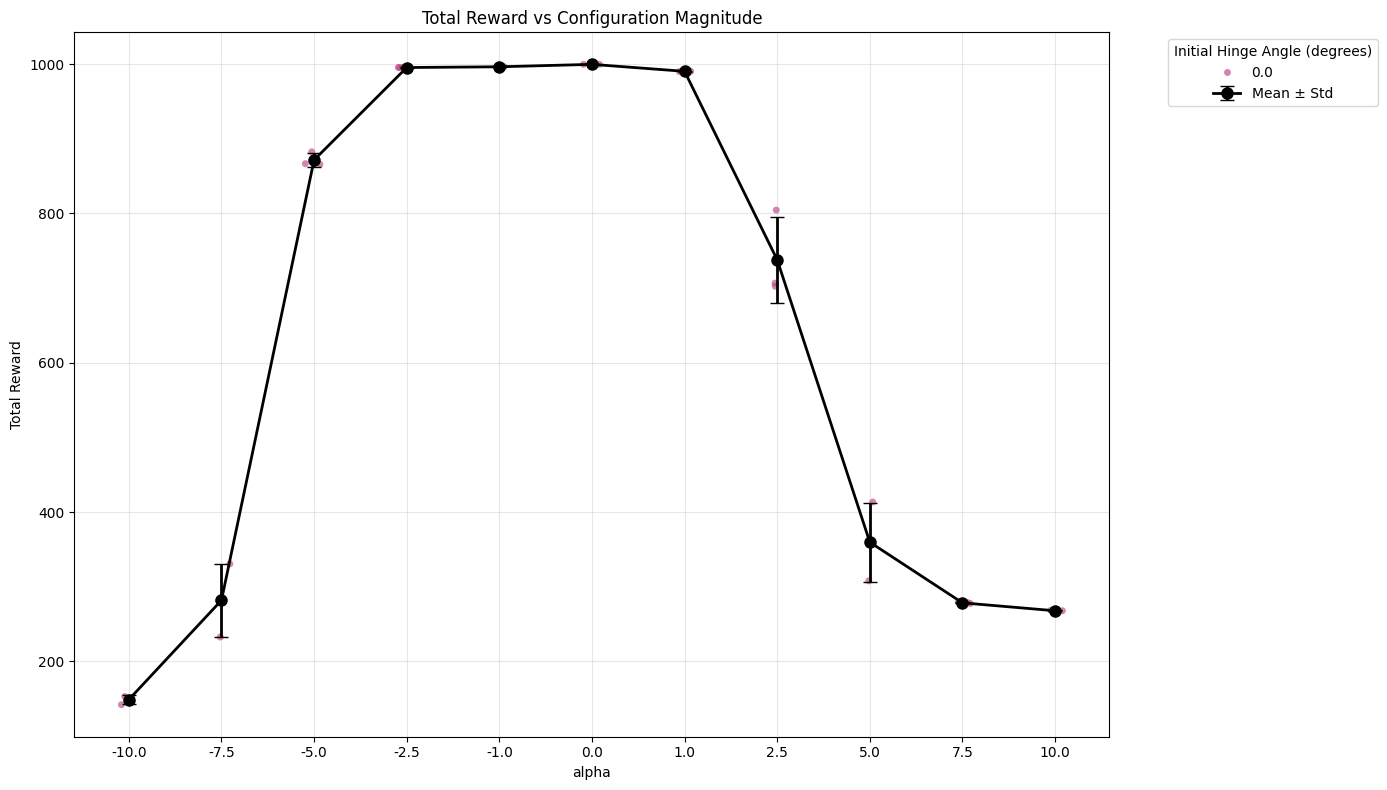

In [27]:
plt.figure(figsize=(14, 8))
sns.stripplot(data=df,
              x='config_magnitude',
              y='total_reward',
              hue='hinge_str',
              hue_order=sorted(df['hinge_str'].unique(),
                               key=lambda x: float(x)),
              alpha=0.6,
              palette='magma')

# Calculate mean and std per config_magnitude
grouped = df.groupby('config_magnitude')['total_reward'].agg(['mean', 'std'])
x_positions = range(len(grouped))
magnitudes = grouped.index

# Plot mean with error bars
plt.errorbar(x_positions,
             grouped['mean'],
             yerr=grouped['std'],
             fmt='-o',
             color='black',
             markersize=8,
             capsize=5,
             linewidth=2,
             label='Mean ± Std',
             zorder=10)

plt.xlabel('alpha')
plt.ylabel('Total Reward')
plt.title('Total Reward vs Configuration Magnitude')
plt.grid(True, alpha=0.3)
plt.legend(title='Initial Hinge Angle (degrees)',
           bbox_to_anchor=(1.05, 1),
           loc='upper left')
plt.tight_layout()
plt.show()

In [28]:
df = compute_success(df, consecutive_steps=200, column_name='success_200')

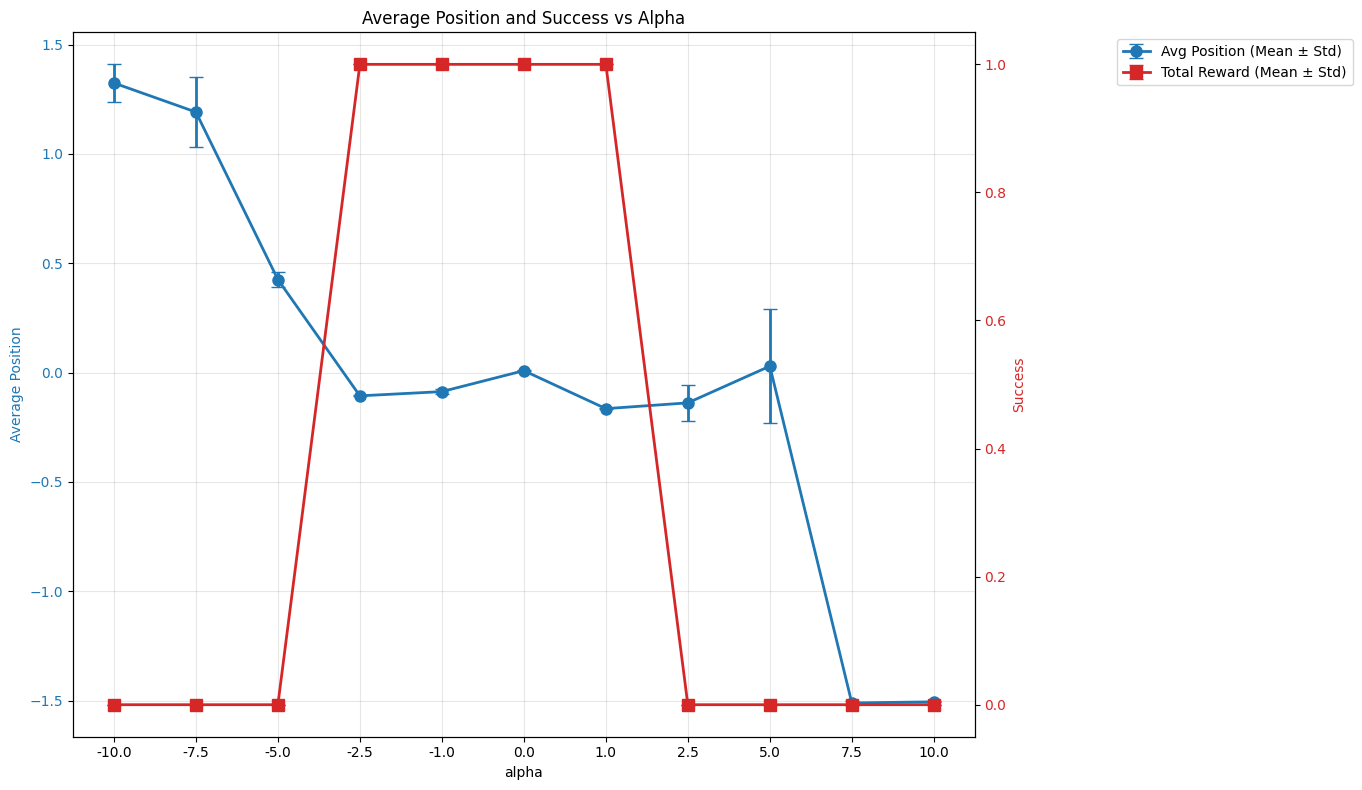

In [29]:
fig, ax1 = plt.subplots(figsize=(14, 8))

# Prepare x labels (alphas)
grouped_pos = df.groupby('config_magnitude')['average_dim_0'].agg(
    ['mean', 'std'])
alphas = grouped_pos.index
x_positions = range(len(alphas))

# Left y-axis: Average Position
ax1.set_xlabel('alpha')
ax1.set_ylabel('Average Position', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Plot average position with error bars
ax1.errorbar(x_positions,
             grouped_pos['mean'],
             yerr=grouped_pos['std'],
             fmt='-o',
             color='tab:blue',
             markersize=8,
             capsize=5,
             linewidth=2,
             label='Avg Position (Mean ± Std)',
             zorder=10)

# Right y-axis: Total Reward
ax2 = ax1.twinx()
ax2.set_ylabel('Success', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Calculate mean and std for total_reward per config_magnitude
grouped_reward = df.groupby('config_magnitude')['success_200'].agg(
    ['mean', 'std'])

# Plot total reward with error bars
ax2.errorbar(x_positions,
             grouped_reward['mean'],
             yerr=grouped_reward['std'],
             fmt='-s',
             color='tab:red',
             markersize=8,
             capsize=5,
             linewidth=2,
             label='Total Reward (Mean ± Std)',
             zorder=10)

# Set alphas as x-axis labels
ax1.set_xticks(x_positions)
ax1.set_xticklabels([str(alpha) for alpha in alphas])

plt.title('Average Position and Success vs Alpha')
ax1.grid(True, alpha=0.3)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2,
           labels1 + labels2,
           bbox_to_anchor=(1.15, 1),
           loc='upper left')

plt.tight_layout()
plt.show()

## Analysis on the latent states

/scratch/slurm_tmpdir/job_1589013/ipykernel_1790701/1122516518.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(all_latent_values, labels=magnitudes)


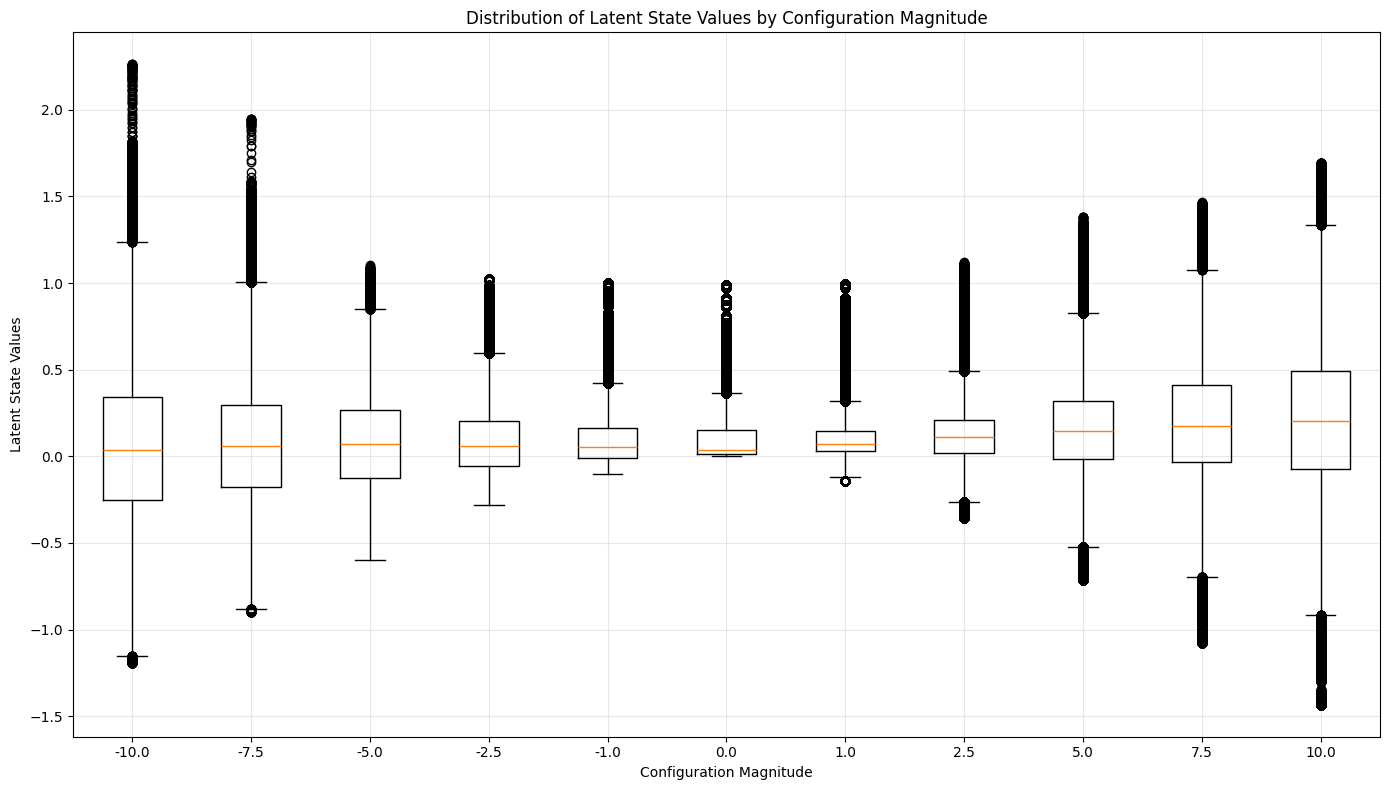

In [30]:
# Collect all latent states for each config_magnitude
all_latent_values = []
magnitudes = sorted(df['config_magnitude'].unique())

for magnitude in magnitudes:
    # Get all latent states for this magnitude
    latent_states = df[df['config_magnitude'] == magnitude]['latent_states']

    # Flatten all latent states into a single list
    flattened = []
    for episode_latents in latent_states:
        flattened.extend(episode_latents.flatten())

    all_latent_values.append(flattened)

# Create box plot
plt.figure(figsize=(14, 8))
plt.boxplot(all_latent_values, labels=magnitudes)
plt.xlabel('Configuration Magnitude')
plt.ylabel('Latent State Values')
plt.title('Distribution of Latent State Values by Configuration Magnitude')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/scratch/slurm_tmpdir/job_1589013/ipykernel_1790701/2754535183.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(all_latent_values,


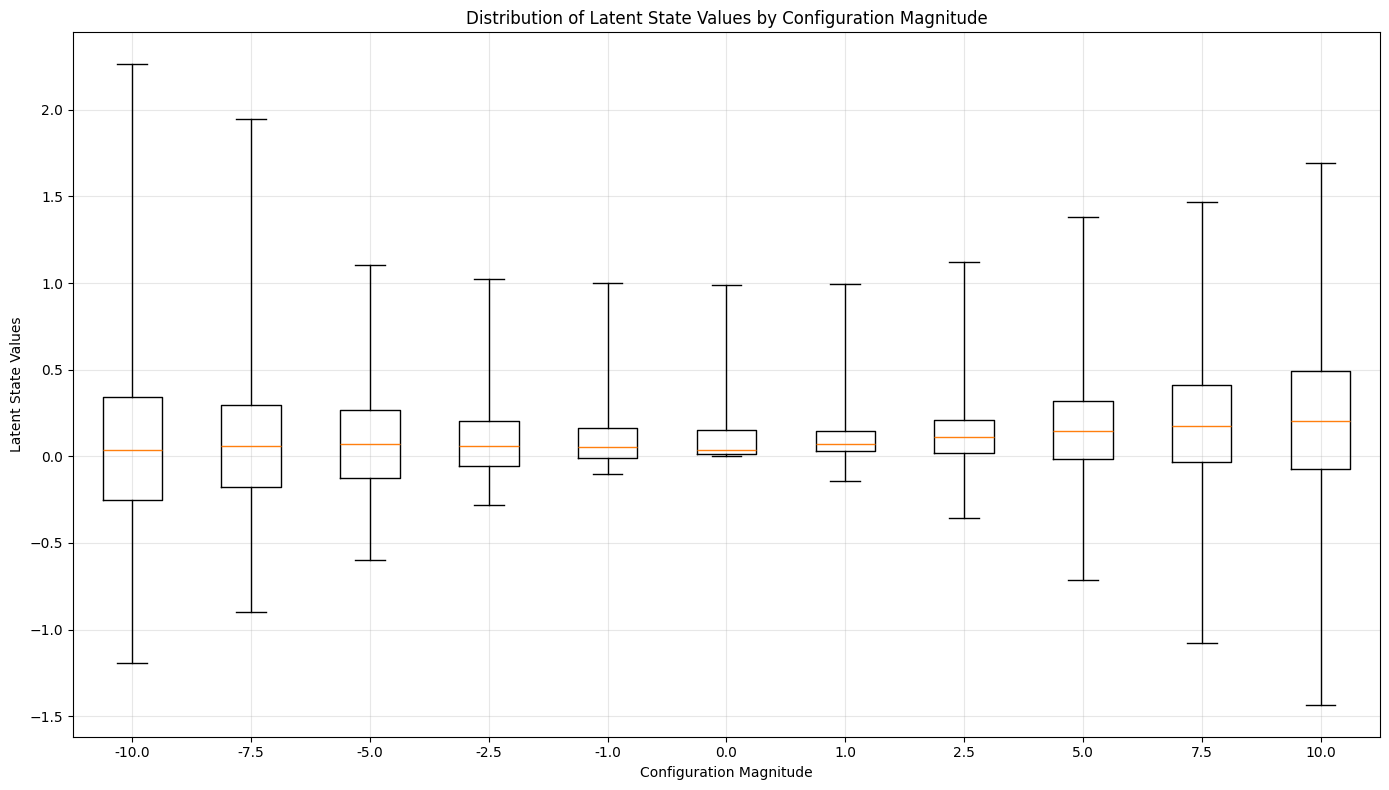

In [31]:
# Collect all latent states for each config_magnitude
all_latent_values = []
magnitudes = sorted(df['config_magnitude'].unique())

for magnitude in magnitudes:
    # Get all latent states for this magnitude
    latent_states = df[df['config_magnitude'] == magnitude]['latent_states']

    # Flatten all latent states into a single list
    flattened = []
    for episode_latents in latent_states:
        flattened.extend(episode_latents.flatten())

    all_latent_values.append(flattened)

# Create box plot with min/max whiskers instead of fliers
plt.figure(figsize=(14, 8))
plt.boxplot(all_latent_values,
            labels=magnitudes,
            showfliers=False,
            whis=[0, 100])
plt.xlabel('Configuration Magnitude')
plt.ylabel('Latent State Values')
plt.title('Distribution of Latent State Values by Configuration Magnitude')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
